In [ ]:
### in this task missing values *should be imputed* with the mean value of the column
### impute missing values only in columns required for solutions

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'figure.figsize': (8, 4)})

import numpy as np
from scipy.constants import pound, ounce
from statistics import NormalDist

#%matplotlib inline
#import matplotlib_inline
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import seaborn as sns
sns.set()

In [34]:
df = pd.read_csv("amazon_books_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946 entries, 0 to 945
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        946 non-null    object 
 1   author       824 non-null    object 
 2   price        944 non-null    float64
 3   pages        934 non-null    float64
 4   avg_reviews  823 non-null    float64
 5   n_reviews    946 non-null    int64  
 6   dimensions   914 non-null    object 
 7   weight       943 non-null    object 
 8   language     943 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 66.6+ KB


#### Question 1

In [35]:
### decide what data type each column is: numerical-discrete, numerical-continuous, categorical-nominal, categorical-ordinal
### consider only [price, pages, avg_reviews, n_reviews, language] for this analysis
### no need to add explanations, just the final answer

# price - numerical-continuous, 
# pages - numerical-discrete,
# avg_reviews - numerical-continuous,
# n_reviews - numerical-discrete,
# language - categorical-nominal.

columns = ['price', 'pages', 'avg_reviews', 'n_reviews', 'language']
data_types = ['numerical-continuous', 'numerical-discrete', 'numerical-continuous', 'numerical-discrete', 'categorical-nominal']

result_q1 = pd.DataFrame({
    'column': columns,
    'data type': data_types
})
result_q1

,column,data type
0,price,numerical-continuous
1,pages,numerical-discrete
2,avg_reviews,numerical-continuous
3,n_reviews,numerical-discrete
4,language,categorical-nominal


#### Question 2

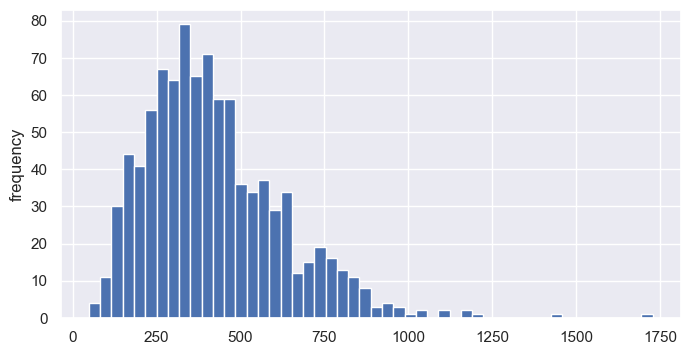


Skewed positive as shown in histogram, and mean > median.



count     934.000000
mean      419.356531
std       203.984911
min        48.000000
25%       272.000000
50%       384.000000
75%       531.500000
max      1728.000000
Name: pages, dtype: float64

In [36]:
### plot a histogram of books' number of pages using 50 bins
### decide if the distribution is symmetric, skewed positive or skewed negative
### use both the histogram and required computations for this decision

plt.hist(df['pages'], bins=50)
plt.ylabel('frequency')
plt.show()

print('\nSkewed positive as shown in histogram, and mean > median.\n') 

decribe_pages = df['pages'].describe()
decribe_pages




#### Question 3

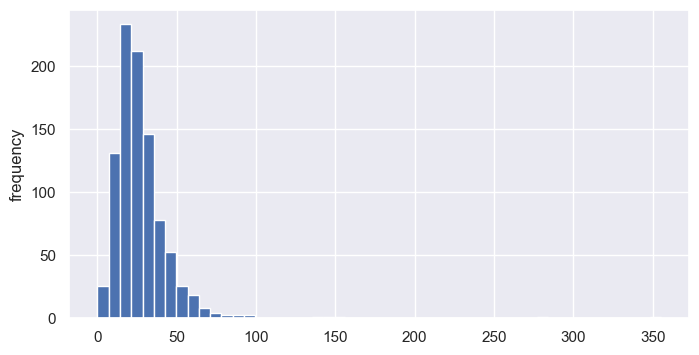


Skewed positive as shown in histogram, and mean > median.



count    943.000000
mean      27.431607
std       20.572252
min        0.035000
25%       17.040000
50%       23.680000
75%       32.800000
max      355.200000
Name: weight ounces, dtype: float64

In [45]:
### inspect the 'weight' column carefully
### plot a histogram of books' weight using 50 bins
### decide if the distribution is symmetric, skewed positive or skewed negative
### use both the histogram and required computations for this decision

conversion_factor_pound_to_ounce = pound / ounce

# new data frame that has the column of weight splitted into columns of weight value and weight unit
df_split_weight_column_to_float_and_str_columns = df.copy()
df_split_weight_column_to_float_and_str_columns[['weight value', 'weight unit']] = df_split_weight_column_to_float_and_str_columns['weight'].str.split(' ', expand=True)
df_split_weight_column_to_float_and_str_columns['weight value'] = df_split_weight_column_to_float_and_str_columns['weight value'].astype(float)

# convertion all weight values to ounces ignore values with no weight unit
conditions = [
    df_split_weight_column_to_float_and_str_columns['weight unit'].str.contains('pound', na=False),  
    df_split_weight_column_to_float_and_str_columns['weight unit'].str.contains('ounce', na=False)   
]
choices = [
    df_split_weight_column_to_float_and_str_columns['weight value'] * conversion_factor_pound_to_ounce,             
    df_split_weight_column_to_float_and_str_columns['weight value']                                  
]

df_split_weight_column_to_float_and_str_columns['weight ounces'] = np.select(conditions, choices, default=np.nan)

plt.hist(df_split_weight_column_to_float_and_str_columns['weight ounces'], bins=50)
plt.ylabel('frequency')
plt.show()

print('\nSkewed positive as shown in histogram, and mean > median.\n') 

decribe_pages = df_split_weight_column_to_float_and_str_columns['weight ounces'].describe()
decribe_pages


#### Question 4

In [38]:
### compute Pearson's correlation between a book's volume (inferred by its dimensions) and price in the data
### (you can use the built-in Series.corr() function for that purpose)

# cleaning dimensions column from inches and x, splitting to floats columns
df_with_volume = df['dimensions'].str.replace(' inches', '', regex=False)
df_with_volume = df_with_volume.str.split(' x ', expand=True)
df_with_volume = df_with_volume.astype(float)

# calculate volume and add price from original df
df_with_volume['volume'] = df_with_volume[0] * df_with_volume[1] * df_with_volume[2]
df_with_volume['price'] = df['price']

# compute corr
volume_price_correlation = df_with_volume['volume'].corr(df_with_volume['price'])

print("Pearson's correlation between volume and price is:", volume_price_correlation)

Pearson's correlation between volume and price is: 0.4318639463444666


#### Question 5

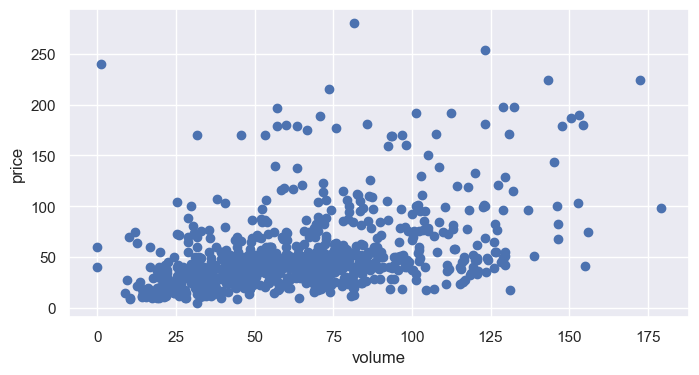

In [39]:
### show a scatter plot of a book's volume (inferred by its dimensions) and price
### do the results fit the score you got in the previous cell? (no need to print answer to this question)

plt.scatter(df_with_volume['volume'], df_with_volume['price'])
plt.xlabel('volume')
plt.ylabel('price')
plt.show()

#### Question 6

In [40]:
### inspect book titles carefully: they can be roughly split by keyphrases:
### ['data science', 'data analytics', 'data engineering', 'machine learning', 'statistics', 
### 'deep learning', 'natural language processing']

### a book belongs to one of the above categories if its name contains the corresponding keyphrase
### display the number of books that fall into each category and their total, in the same table
### some books may not belong to any of the listed above categories
### category match should be case insensitive


keywords = ['data science', 'data analytics', 'data engineering', 'machine learning', 
            'statistics', 'deep learning', 'natural language processing']

category_count_dict = {}  # counter for each category

# create new df with the title in lower case (case insensitive), and with a boolean column to count only one time per book (for their total)
df_books_title_lower_case = pd.DataFrame()
df_books_title_lower_case['title'] = df['title'].str.lower()
df_books_title_lower_case['counted'] = False

# sum per keyword and update counted column
for keyword in keywords:
    matches = df_books_title_lower_case['title'].str.contains(keyword, na=False)
    count = matches.sum()
    category_count_dict[keyword] = count
    df_books_title_lower_case.loc[matches, 'counted'] = True # mark relevant row as counted
    
category_count_dict['total'] = df_books_title_lower_case['counted'].sum() # count how many trues

result_q6 = pd.DataFrame(list(category_count_dict.items()), columns=['category', 'number of books'])
result_q6

,category,number of books
0,data science,111
1,data analytics,28
2,data engineering,7
3,machine learning,179
4,statistics,128
5,deep learning,138
6,natural language processing,13
7,total,528


#### Question 7

In [41]:
### display the same result where the dataframe is sorted by the number of books, descending
### no need to display the total amount in this result - drop it

result_q7 = result_q6[result_q6['category'] != 'total']                  # drop the total row
result_q7 = result_q7.sort_values(by='number of books', ascending=False) # sort by number of books
result_q7 = result_q7.reset_index(drop = True)                           # reset the index and drop the before index
result_q7

,category,number of books
0,machine learning,179
1,deep learning,138
2,statistics,128
3,data science,111
4,data analytics,28
5,natural language processing,13
6,data engineering,7


#### Question 8

In [42]:
### sample 10000 values from N~(50, 10)
### for this pirpose use https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

### what portion of the distribution is found in the range (42.5, 57.5)? -- calculate using z table
### (recall the NormalDist().cdf() function we used at the lecture)

### what portion of the distribution is found in the range (42.5, 57.5)? -- compute empirically using the sampled values
### report both values (calculated and empirical)

# calculte distance according to the formula: (42.5 - 50) / 10 = -0.75, (57.5 - 50) / 10 = 0.75
z_score = NormalDist().cdf(0.75) - NormalDist().cdf(-0.75)

# sample and calculate empirically
sample = np.random.normal(50, 10, 10000)
empirical_score = np.sum((sample > 42.5) & (sample < 57.5)) / 10000

# build and show table
result_q8 = pd.DataFrame()
result_q8['type'] = 'empirical score', 'z score'
result_q8['value'] = empirical_score, z_score
result_q8

,type,value
0,empirical score,0.544200
1,z score,0.546745


#### Question 9

In [43]:
### compute confidence interval of 90% for the true population mean of a book price on Amazon
### report left and right boundaries

z_score = 1.64     # according to z table

prices = df['price'].fillna(df['price'].mean()) # fill empty cells with mean 
sample_mean = prices.mean()

se = prices.std() / np.sqrt(len(prices))    # according to formula

left_boundary = sample_mean - (z_score * se)
right_boundary = sample_mean + (z_score * se)

result_q9 = pd.DataFrame({
                            'left boundary': [left_boundary],
                            'right boundary': [right_boundary]
                         })
result_q9

,left boundary,right boundary
0,50.154539,54.052516


#### Question 10

In [44]:
### can one say with 85% confidence that the true population mean of a book price resides within the [49.0, 54.0] interval?
### show your computations, and print your answer: yes or no

z_score = 1.44     # according to z table

prices = df['price'].fillna(df['price'].mean()) 
sample_mean = prices.mean()

se = prices.std() / np.sqrt(len(prices))    # according to formula

left_boundary = sample_mean - (z_score * se)
right_boundary = sample_mean + (z_score * se)

result_q10 = pd.DataFrame({
                            'left boundary': [left_boundary, 49.0],
                            'right boundary': [right_boundary, 54.0]
                         })
print('yes, as shown:\n')
result_q10.index = ['computation', 'suggestion']
result_q10

yes, as shown:



,left boundary,right boundary
computation,50.392221,53.814834
suggestion,49.000000,54.000000
